In [1]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt
import atn.ATN as ATN
import tool.common as cm
import mnist_attak.train_cnn
import atn_train
sigmoid_norm = atn_train.sigmoid_norm
CNN_1 = mnist_attak.train_cnn.CNN_1
CNN_2 = mnist_attak.train_cnn.CNN_2
nn = torch.nn
_, __, x_test, y_test = cm.load_data('mnist')
del _
del __
import gc
gc.collect()

/usr/local/lib/python2.7/site-packages/torchvision/datasets/mnist.py:53: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")
/usr/local/lib/python2.7/site-packages/torchvision/datasets/mnist.py:43: UserWarning: train_labels has been renamed targets
  warnings.warn("train_labels has been renamed targets")
/usr/local/lib/python2.7/site-packages/torchvision/datasets/mnist.py:58: UserWarning: test_data has been renamed data
  warnings.warn("test_data has been renamed data")
/usr/local/lib/python2.7/site-packages/torchvision/datasets/mnist.py:48: UserWarning: test_labels has been renamed targets
  warnings.warn("test_labels has been renamed targets")
tool/common.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = tc.tensor(X_test,dtype=tc.float) / 255
tool/common.py:42: UserWarning: To 

3

## File name convention:
Two different kinds of GATN (GATN_FC/GATN_CONV), two different kinds of CNN (CNN_1/CNN_2), ten differnet target, in total 40 models

for example, 'GatnFC_mnistCNN_1_target7' is GatnFC trained on MNIST of classifer type CNN_1 and target 7

to see the result, please follow instruction below:

#### 1. specify what mnist classifer you want to attack
change following code
```python
CNN_FILE_PATH = 'data/mnist_CNN_2_model_params.pkl' # if you attack CNN_2, change 1 to 2
cnn_mnist = CNN_2() # if you attack CNN_2, change 1 to 2
```
#### 2. specify the Gatn you used to attack
```python
ATN_FILE_PATH = 'data/GatnFC_mnistCNN_2_target0.parameter' 
# if you attack CNN_1, change CNN_1 to CNN_2
# change the target number to one of 0-9 you with to attack BOTH in the FILE_PATH and target
target = 0
# if you use GatnConv to attack, change 'GatnFC' to 'GatnConv' in FILE_PATH and use ATN.GATN_Conv
atn = ATN.GATN_FC()
```
#### 3. change idx below and start exploring
the idx should be a number in 0-9999, naming one of MNIST test set example

In [2]:
# loading 
CNN_FILE_PATH = 'data/mnist_CNN_2_model_params.pkl'
cnn_mnist = CNN_2()
cnn_mnist.load_state_dict(torch.load(CNN_FILE_PATH))

ATN_FILE_PATH = 'data/GatnConv_mnistCNN_2_target0.parameter'
atn = ATN.GATN_Conv()
atn.load_state_dict(torch.load(ATN_FILE_PATH))
target = 0

# calculating accuracy and target rate
x_test_grad = atn_train.cal_grad_target(x_test, cnn_mnist, target)
x_adv_test = atn(x_test, x_test_grad)
y_pred = cnn_mnist(x_adv_test)
acc, targetrate = atn_train.accuracy(y_pred, y_test, target)
print('|test accuracy:%.4f' % acc, '|target rate:%.4f' % targetrate)

('|test accuracy:0.0000', '|target rate:0.0000')


In [3]:
idx1 = 2070
idx2 = 2009
idx3 = 9843
idx = idx3

### This is original image and original output class

tensor([[7.7167e-07, 9.9998e-01, 4.4641e-06, 2.8023e-07, 5.0552e-06, 5.3193e-07,
         7.4342e-07, 5.3863e-06, 1.5960e-06, 1.3993e-07]],
       grad_fn=<DivBackward0>)


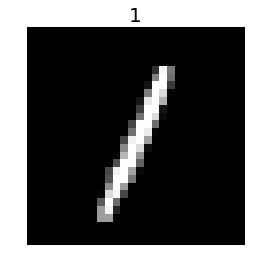

('abc: ', 1)


In [4]:
idx += 1
x_original = x_test[idx].reshape(1,1,28,28)

before_pro = cnn_mnist(x_original)

print(before_pro)

cm.imshow(x_original, torch.argmax(before_pro,dim=1).item())

print("abc: ", torch.argmax(before_pro,dim=1).item())

### This is adversarial image and attacked output class

tensor([[5.1559e-01, 4.7097e-01, 6.9541e-03, 3.9545e-04, 6.7856e-05, 2.9735e-04,
         2.4184e-03, 7.8499e-04, 2.1296e-03, 3.9136e-04]],
       grad_fn=<DivBackward0>)


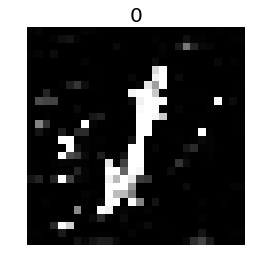

('original probability tensor: ', tensor([[7.7167e-07, 9.9998e-01, 4.4641e-06, 2.8023e-07, 5.0552e-06, 5.3193e-07,
         7.4342e-07, 5.3863e-06, 1.5960e-06, 1.3993e-07]],
       grad_fn=<DivBackward0>))
('adversarial probability tensor: ', tensor([[5.1559e-01, 4.7097e-01, 6.9541e-03, 3.9545e-04, 6.7856e-05, 2.9735e-04,
         2.4184e-03, 7.8499e-04, 2.1296e-03, 3.9136e-04]],
       grad_fn=<DivBackward0>))


In [5]:
x_grad = atn_train.cal_grad_target(x_original, cnn_mnist, target)
x_adv = atn(x_original, x_grad)
#x_adv = atn(x_original) 
x_adv_detach = x_adv.detach()


after_pro = cnn_mnist(x_adv)
print(after_pro)
cm.imshow(x_adv_detach,torch.argmax(after_pro,dim=1).item())
print("original probability tensor: ", before_pro)
print("adversarial probability tensor: ", after_pro )
#print("reranking function", atn_train.reranking(sigmoid_norm(cnn_mnist(x_original)),1, 11) )

### This show the perturbation on the image

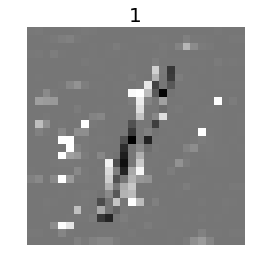

In [6]:
cm.imshow( x_adv_detach - x_original, 1)

## If you have time, you can help write a function that can plot many images at the same time...